<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Msc_Data_Science_Project_N1217583.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Msc Data Science Nikhil Verma N1217583

# Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

# Importing the data directly from kaggle

In [5]:
# Install Kaggle API
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()  # This will prompt you to upload the kaggle.json file

# Move kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset using Kaggle API
!kaggle datasets download -d mohitsingh1804/plantvillage

# Unzip the downloaded file
!unzip plantvillage.zip

Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage/val/Soybean___healthy/52c7d07b-561b-4380-801a-3824e65a5135___RS_HL 3797.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53168d1c-ac90-4039-9eff-7479475a6b74___RS_HL 6355.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5344b09f-bbbe-4a2c-9345-d93dd4e69eb4___RS_HL 4693.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5361ba4a-351e-466c-99c5-8845f35c00df___RS_HL 2890.JPG  
  inflating: PlantVillage/val/Soybean___healthy/537e5409-d824-4859-967f-3c502f13deec___RS_HL 5474.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538969da-545b-4bce-bc1d-0932898dc5e6___RS_HL 5230.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538ccfe2-1509-40d7-beae-ae7cf84e1e5d___RS_HL 3717.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5397bf6a-aeeb-4f1c-b554-bdb604bb23c3___RS_HL 6508.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53dc0466-621c-43e1-9c5e-e340f3d50171___RS_HL 6381.JPG  
  inflating: 

# Reading Data

In [6]:
# Define data paths
TRAIN_DIR = "PlantVillage/train"
VAL_DIR = "PlantVillage/val"
VAL_COPY_DIR = "/kaggle/working/val_copy"
TEST_DIR = "/kaggle/working/test"

In [7]:
import os
import shutil

# Create the new validation directory if it doesn't exist
os.makedirs(VAL_COPY_DIR, exist_ok=True)

# Loop over each class folder in the original validation directory
for class_name in os.listdir(VAL_DIR):
    class_path = os.path.join(VAL_DIR, class_name)
    if os.path.isdir(class_path):
        # Create corresponding class folder in the new validation directory
        new_class_path = os.path.join(VAL_COPY_DIR, class_name)
        os.makedirs(new_class_path, exist_ok=True)

        # Copy all images from the old class folder to the new class folder
        for img_name in os.listdir(class_path):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(new_class_path, img_name)
            shutil.copy2(src, dst)

print("Validation data has been copied to:", VAL_COPY_DIR)

Validation data has been copied to: /kaggle/working/val_copy


# Create Test Directory and Split Validation Data¶

In [8]:
from sklearn.model_selection import train_test_split

# إنشاء مجلد test الجديد
os.makedirs(TEST_DIR, exist_ok=True)

# لكل فئة داخل مجلد val
for class_name in os.listdir(VAL_COPY_DIR):
    class_path = os.path.join(VAL_COPY_DIR, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # إنشاء مجلد الفئة داخل مجلد test
        test_class_dir = os.path.join(TEST_DIR, class_name)
        os.makedirs(test_class_dir, exist_ok=True)

        # نقل الصور إلى مجلد test
        for img_name in test_imgs:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(test_class_dir, img_name)
            shutil.move(src, dst)

# Count Images in Validation and Test Directories

In [9]:
# Count number of images in the validation (val_copy) folder
val_image_count = 0
for class_name in os.listdir(VAL_COPY_DIR):
    class_path = os.path.join(VAL_COPY_DIR, class_name)
    if os.path.isdir(class_path):
        val_image_count += len(os.listdir(class_path))

# Count number of images in the test folder
test_image_count = 0
for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)
    if os.path.isdir(class_path):
        test_image_count += len(os.listdir(class_path))

print(f"Number of images in Validation (val_copy): {val_image_count}")
print(f"Number of images in Test: {test_image_count}")

Number of images in Validation (val_copy): 8676
Number of images in Test: 2185


# Display Random Image Previews from Directory


In [10]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def preview_images_from_directory(directory, num_images=5, title="Preview"):

    categories = os.listdir(directory)
    all_images = []

    for cat in categories:
        cat_path = os.path.join(directory, cat)
        if os.path.isdir(cat_path):
            images = [os.path.join(cat_path, img) for img in os.listdir(cat_path) if img.lower().endswith(('jpg', 'jpeg', 'png'))]
            all_images.extend([(img_path, cat) for img_path in images])


    selected_images = random.sample(all_images, min(num_images, len(all_images)))


    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)

    for i, (img_path, label) in enumerate(selected_images):
        img = mpimg.imread(img_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

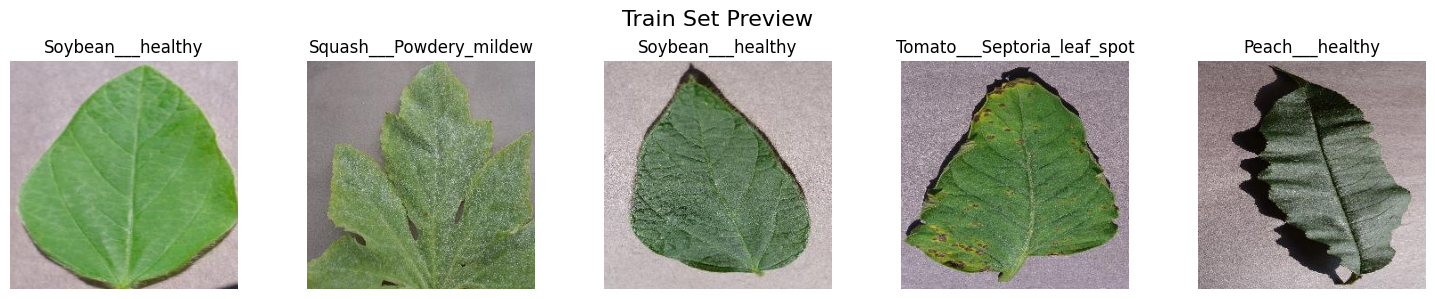

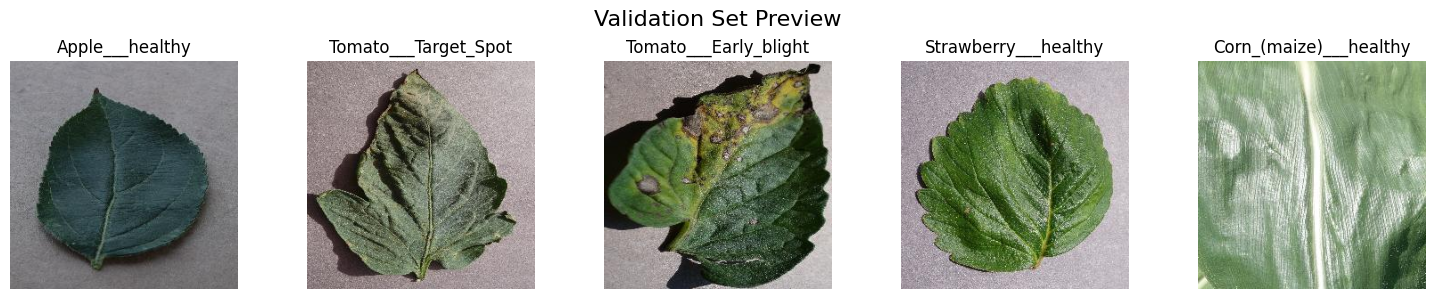

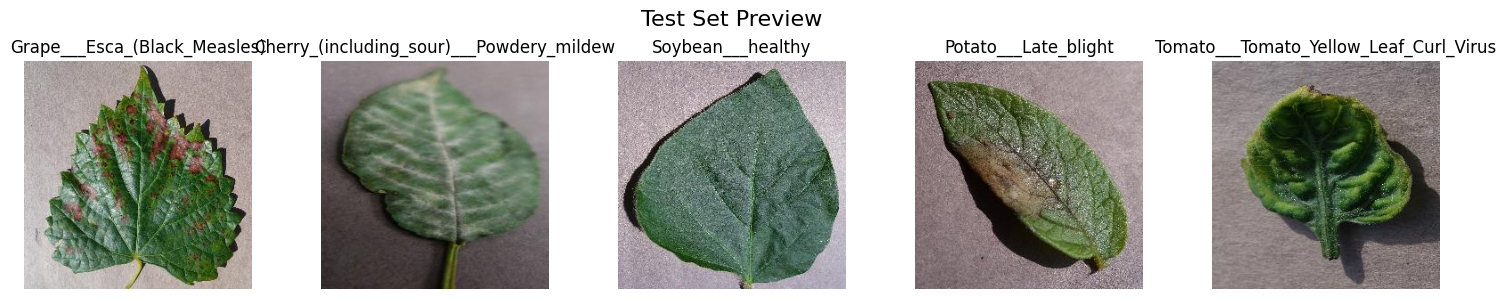

In [22]:
# Training / Testing Set Preview

preview_images_from_directory(TRAIN_DIR, title="Train Set Preview")
preview_images_from_directory(VAL_COPY_DIR, title="Validation Set Preview")
preview_images_from_directory(TEST_DIR, title="Test Set Preview")

# Data Agumentation

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Validation Generator
val_generator = val_datagen.flow_from_directory(
    VAL_COPY_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test Generator
test_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 43444 images belonging to 38 classes.
Found 8676 images belonging to 38 classes.
Found 2185 images belonging to 38 classes.


# Display Sample Images from Training and Validation Generators

Train Generator Class Indices: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tom

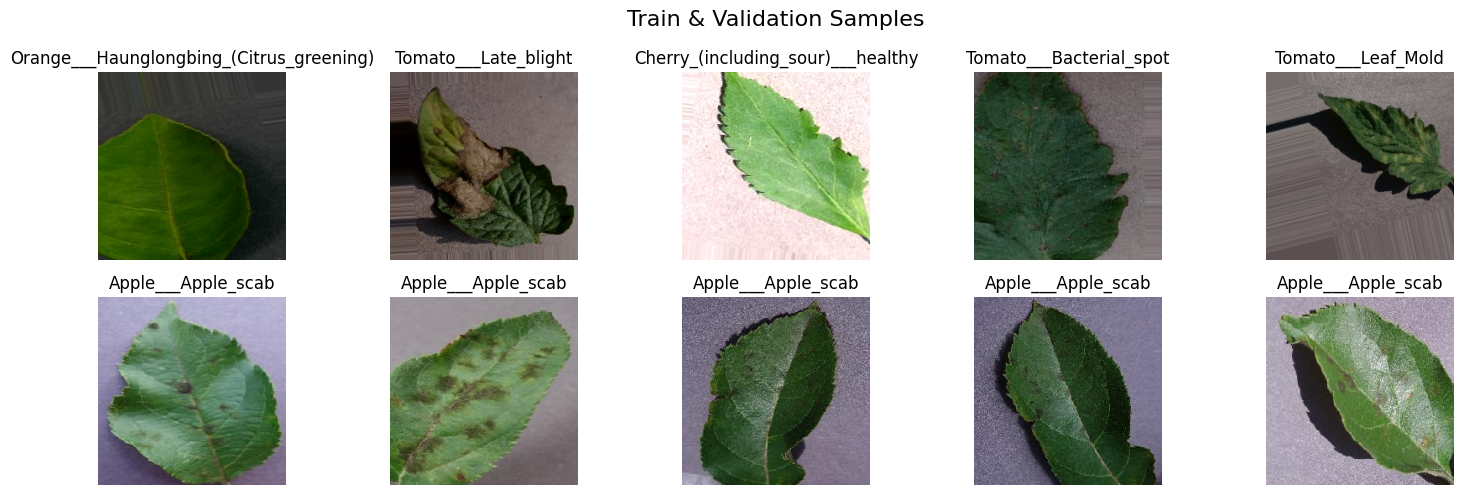

In [12]:
import matplotlib.pyplot as plt
import numpy as np

print("Train Generator Class Indices:", train_generator.class_indices)
print("Validation Generator Class Indices:", val_generator.class_indices)

# train_generator
train_images, train_labels = next(train_generator)
train_class_names = list(train_generator.class_indices.keys())

# val_generator
val_images, val_labels = next(val_generator)
val_class_names = list(val_generator.class_indices.keys())

plt.figure(figsize=(15, 5))

#train_generator
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i])
    plt.title(train_class_names[np.argmax(train_labels[i])])
    plt.axis('off')

# val_generator
for i in range(5):
    plt.subplot(2, 5, i+6)
    plt.imshow(val_images[i])
    plt.title(val_class_names[np.argmax(val_labels[i])])
    plt.axis('off')

plt.suptitle("Train & Validation Samples", fontsize=16)
plt.tight_layout()
plt.show()

# Evaluate and Visualize Model Performance

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize_model(model, test_generator, history=None, model_name="Model"):
    loss, accuracy = model.evaluate(test_generator, verbose=0)
    print(f"\n{model_name} Evaluation:")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())


    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))


    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


    if history is not None:
        plt.figure(figsize=(12, 5))

        # Loss
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Train Loss', marker='o', color='blue')
        plt.plot(history.history['val_loss'], label='Val Loss', marker='o', color='orange')
        plt.title(f'{model_name} - Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        # Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
        plt.title(f'{model_name} - Accuracy Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

# Visualize Model Predictions on Test Images

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import random

def test_model_prediction_with_visuals(model, test_generator, class_names, num_images=9):

    test_generator.reset()
    images, labels = next(test_generator)


    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        idx = random.randint(0, len(images) - 1)
        plt.subplot(int(np.sqrt(num_images)), int(np.sqrt(num_images)), i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        plt.title(f"Actual: {class_names[true_classes[idx]]}\nPred: {class_names[pred_classes[idx]]}",
                  color='green' if true_classes[idx] == pred_classes[idx] else 'red')

    plt.tight_layout()
    plt.show()

# Callbacks to Prevent Overfitting and Improve Performance

In [15]:
class_names = list(train_generator.class_indices.keys())

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# CNN

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(os.listdir(TRAIN_DIR)), activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training the model
history_cnn = model_cnn.fit(train_generator, validation_data=val_generator, epochs=50,
                            callbacks=[early_stop, checkpoint])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
   4/1358 ━━━━━━━━━━━━━━━━━━━━ 1:32:01 4s/step - accuracy: 0.0944 - loss: 4.3356

KeyboardInterrupt: 

In [2]:
evaluate_and_visualize_model(model_cnn, test_generator, history_cnn, model_name="CNN")

NameError: name 'evaluate_and_visualize_model' is not defined

In [ ]:
test_model_prediction_with_visuals(model_cnn, test_generator, class_names)

# MobileNetV2

In [ ]:
# Transfer Learning - MobileNetV2
mobilenetv2_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
mobilenetv2_base.trainable = False  # Freeze the layers

model_mobilenetv2 = Sequential([
    mobilenetv2_base,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(os.listdir(TRAIN_DIR)), activation='softmax')
])

model_mobilenetv2.compile(optimizer=Adam(learning_rate=1e-5),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

# Training MobileNetV2 model
history_mobilenetv2 = model_mobilenetv2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
evaluate_and_visualize_model(model_mobilenetv2, test_generator, history_mobilenetv2, model_name="model_mobilenetv2")

In [ ]:
test_model_prediction_with_visuals(model_mobilenetv2, test_generator, class_names)
model.save("mobilenet.keras")